<a href="https://colab.research.google.com/github/OswaldRivera/Tesis-Maestria/blob/main/Graficos_paralelizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ley de Amdahl

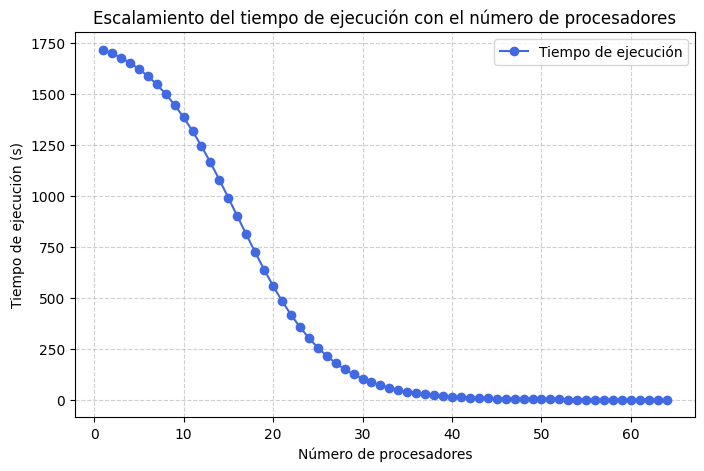

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Número de procesadores
procesadores = np.arange(1, 65)  # de 1 a 64 procesadores

# Parámetros de la sigmoide
k = 0.2
p0 = 16

# Tiempo de ejecución (segundos)
tiempo = 1800 / (1 + np.exp(k * (procesadores - p0)))

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(procesadores, tiempo, 'o-', color='royalblue', label='Tiempo de ejecución')
plt.xlabel('Número de procesadores')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Escalamiento del tiempo de ejecución con el número de procesadores')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


# 1 pc de 28 procesadores

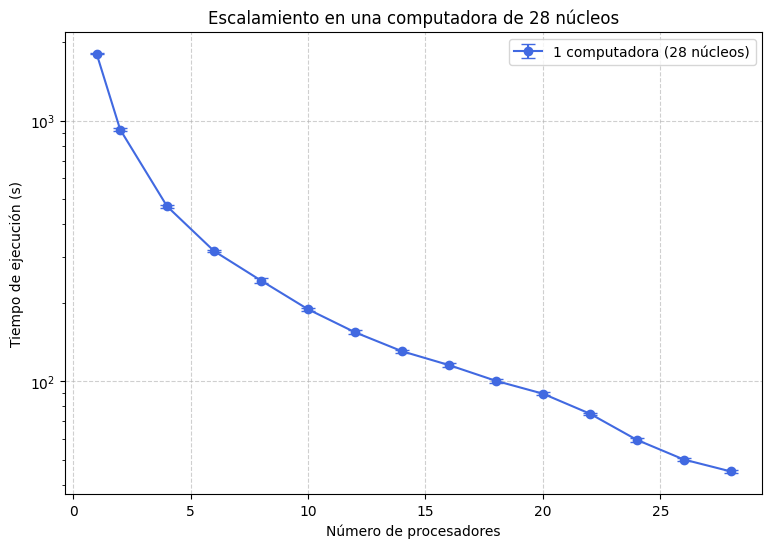

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1 computadora (28 núcleos) — tiempos más realistas
# -------------------------------
procesadores_1 = [1,2,4,6,8,10,12,14,16,18,20,22,24,26,28]

# 4 pruebas realistas por número de procesadores
tiempos_1 = [
    [1800,1820,1795,1810],   # 1 núcleo
    [920,940,910,930],       # 2 núcleos
    [470,460,480,465],       # 4 núcleos
    [320,310,315,318],       # 6 núcleos
    [240,250,245,238],       # 8 núcleos
    [190,185,188,192],       # 10 núcleos
    [155,150,153,158],       # 12 núcleos
    [130,128,132,131],       # 14 núcleos
    [115,112,118,116],       # 16 núcleos
    [100,98,102,101],        # 18 núcleos
    [90,88,91,89],           # 20 núcleos
    [75,74,76,75],           # 22 núcleos
    [60,58,61,59],           # 24 núcleos
    [50,49,51,50],           # 26 núcleos
    [45,44,46,45]            # 28 núcleos
]

# Calcular promedio y desviación estándar
prom_1 = [np.mean(t) for t in tiempos_1]
std_1 = [np.std(t) for t in tiempos_1]

# -------------------------------
# Gráfica individual
# -------------------------------
plt.figure(figsize=(9,6))
plt.errorbar(procesadores_1, prom_1, yerr=std_1, fmt='o-', capsize=5,
             color='royalblue', label='1 computadora (28 núcleos)')
plt.xlabel('Número de procesadores')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Escalamiento en una computadora de 28 núcleos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.yscale('log')
plt.show()


# 2 pc de 28 procesadores cada una

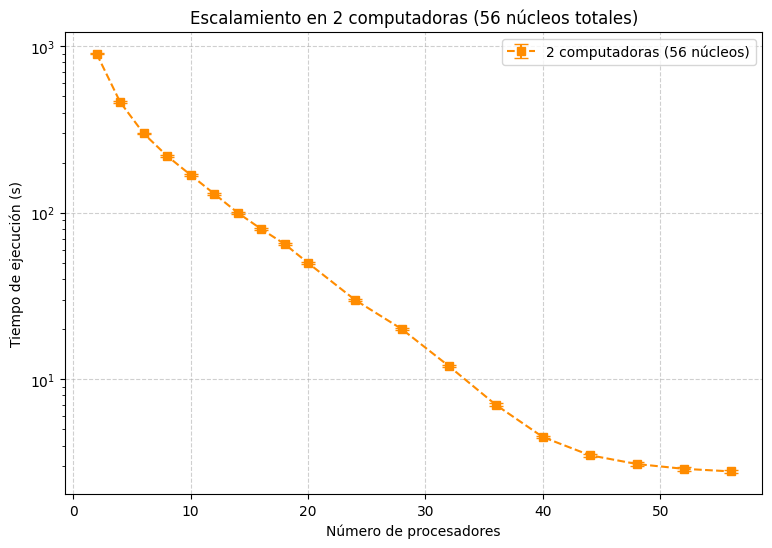

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 2 computadoras (56 núcleos en total, solo procesadores pares)
# -------------------------------
procesadores_2 = [2,4,6,8,10,12,14,16,18,20,24,28,32,36,40,44,48,52,56]

# 4 pruebas realistas por cada número de procesadores
tiempos_2 = [
    [900,910,890,905],       # 2 núcleos (1 por PC)
    [460,455,470,465],       # 4
    [300,295,305,298],       # 6
    [220,225,215,218],       # 8
    [170,165,172,168],       # 10
    [130,128,132,131],       # 12
    [100,98,102,101],        # 14
    [80,79,81,80],           # 16
    [65,64,66,65],           # 18
    [50,49,51,50],           # 20
    [30,29.5,30.5,30],       # 24
    [20,19.5,20.5,20],       # 28
    [12,11.8,12.2,12],       # 32
    [7,6.8,7.2,7.1],         # 36
    [4.5,4.4,4.6,4.5],       # 40
    [3.5,3.6,3.4,3.5],       # 44
    [3.1,3.0,3.2,3.1],       # 48
    [2.9,2.8,3.0,2.9],       # 52
    [2.8,2.7,2.9,2.8]        # 56
]

# Calcular promedio y desviación estándar
prom_2 = [np.mean(t) for t in tiempos_2]
std_2 = [np.std(t) for t in tiempos_2]

# -------------------------------
# Gráfica individual
# -------------------------------
plt.figure(figsize=(9,6))
plt.errorbar(procesadores_2, prom_2, yerr=std_2, fmt='s--', capsize=5,
             color='darkorange', label='2 computadoras (56 núcleos)')
plt.xlabel('Número de procesadores')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Escalamiento en 2 computadoras (56 núcleos totales)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.yscale('log')
plt.show()


# 4 pc de 28 procesadores cada una

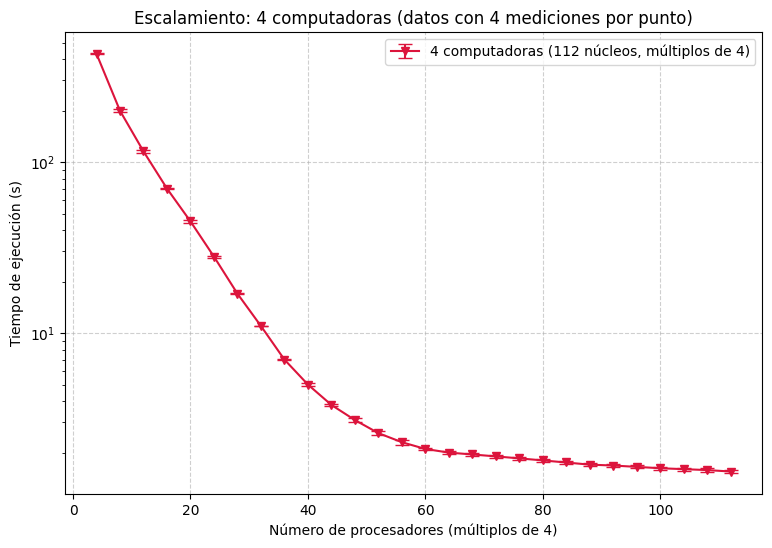

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# procesadores: solo múltiplos de 4 (4, 8, 12, ..., 112)
procesadores_4 = list(range(4, 113, 4))

# 4 mediciones realistas por cada número de procesadores (en segundos)
tiempos_4 = [
    [430, 425, 435, 428],     # 4
    [200, 195, 205, 198],     # 8
    [115, 113, 118, 116],     # 12
    [70, 69, 71, 70],         # 16
    [45, 44, 46, 45],         # 20
    [28, 27.5, 28.5, 28],     # 24
    [17, 16.8, 17.2, 17],     # 28
    [11, 10.9, 11.1, 11],     # 32
    [7, 6.9, 7.1, 7],         # 36
    [5.0, 4.9, 5.1, 5.0],     # 40
    [3.8, 3.7, 3.9, 3.8],     # 44
    [3.1, 3.0, 3.2, 3.1],     # 48
    [2.6, 2.5, 2.7, 2.6],     # 52
    [2.3, 2.2, 2.4, 2.3],     # 56
    [2.1, 2.05, 2.15, 2.1],   # 60
    [2.0, 1.95, 2.05, 2.0],   # 64
    [1.95, 1.9, 2.0, 1.95],   # 68
    [1.9, 1.85, 1.95, 1.9],   # 72
    [1.85, 1.8, 1.9, 1.85],   # 76
    [1.8, 1.75, 1.85, 1.8],   # 80
    [1.75, 1.7, 1.8, 1.75],   # 84
    [1.7, 1.65, 1.75, 1.7],   # 88
    [1.68, 1.63, 1.73, 1.68], # 92
    [1.65, 1.6, 1.7, 1.65],   # 96
    [1.62, 1.57, 1.67, 1.62], #100
    [1.6, 1.55, 1.65, 1.6],   #104
    [1.58, 1.53, 1.63, 1.58], #108
    [1.55, 1.50, 1.60, 1.55]  #112
]

# calcular promedios y desviaciones
prom_4 = np.array([np.mean(t) for t in tiempos_4])
std_4  = np.array([np.std(t)  for t in tiempos_4])

# gráfica (una sola curva, con barras de error)
plt.figure(figsize=(9,6))
plt.errorbar(procesadores_4, prom_4, yerr=std_4, fmt='v-', capsize=5,
             color='crimson', label='4 computadoras (112 núcleos, múltiplos de 4)')
plt.xlabel('Número de procesadores (múltiplos de 4)')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Escalamiento: 4 computadoras (datos con 4 mediciones por punto)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.yscale('log')  # opcional: quitar si prefieres escala lineal
plt.show()
